In [1]:
import os
import pandas as pd
import time
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scripts.train_model import circuit_training, train_five_times
from scr.qsvdd_core.data_loader import QuantumDataLoader
from scripts.test_model import test, mean_auc
import json

In [2]:
n_train = 0 ; latent_dim = 3
learning_rate = 0.001

In [3]:
print("Current directory:", os.getcwd())
print("Files in directory:", os.listdir())

Diretório atual: D:\projects\QSVDD2\notebooks
Arquivos nesta pasta: ['circuit_visualization.ipynb', 'noise_data_visualization.ipynb', 'original_qcnn_experiments', 'training_test_data.ipynb', 'training_test_data_with_pca.ipynb', 'visualization.ipynb']


In [4]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Successfully loaded dataset.\n")
print("First 5 records:\n", df.head())

Dataset carregado com sucesso!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141

In [5]:
loader = QuantumDataLoader()

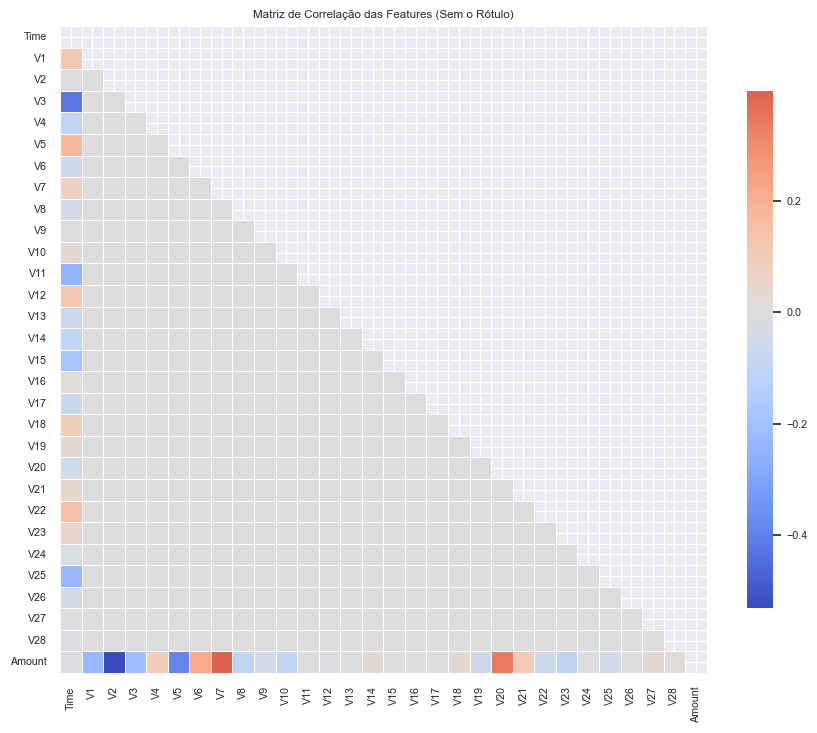

In [6]:
loader.plot_correlation_matrix(df)

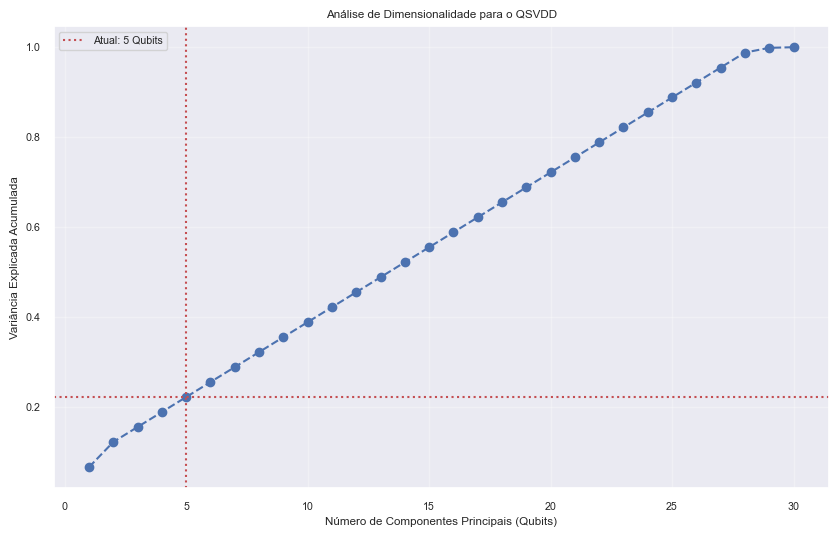

Variância com 5 qubits: 22.14%


In [7]:
loader.plot_explained_variance(df)

In [8]:
X_quantum, y = loader.prepare_pca_data(df)

print(f"Features for the circuit: {X_quantum.shape}")
print(f"Labels: {y.shape}")

Explained Variance Ratio:  [0.06527521 0.05612313 0.03333333 0.03333333 0.03333333]
Singular Values:  [746.80996609 692.47948309 533.67312093 533.67312093 533.67312093]
Features para o circuito: (284807, 5)
Labels: (284807,)


In [9]:
"""
One-class Training:
"""
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]
np.random.seed(42)

X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train_normal = X_quantum[X_train_normal_indices]
y_train_normal = y[X_train_normal_indices]

X_train = X_train_normal
Y_train = y_train_normal

remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_normal = X_quantum[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)
X_test_abnormal = X_quantum[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)


center = np.zeros(latent_dim)
center_train = np.tile(center, (len(X_train), 1))


print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test_normal shape: {X_test_normal.shape}')
print(f'X_test_abnormal shape: {X_test_abnormal.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')
print(f'center_train shape: {center_train.shape}')

X_train shape: (1000, 5)
Y_train shape: (1000,)
X_test_normal shape: (100, 5)
X_test_abnormal shape: (100, 5)
X_test shape: (200, 5)
Y_test shape: (200,)
center_train shape: (1000, 3)


In [10]:
train_Xdata = X_train
train_Ydata = center_train

In [11]:
qcnn_batch_size = 4
qcnn_steps = 16*500//qcnn_batch_size

In [12]:
qcnn_batch_size = 4
qcnn_steps = 16*500//qcnn_batch_size
qcnn_matrix_of_parameters = train_five_times(X_train=train_Xdata,
                                             Y_train=train_Ydata,
                                             batch_size=qcnn_batch_size,
                                             learning_rate=learning_rate,
                                             steps=qcnn_steps,
                                             ansatz='qcnn',
                                             fm='angle_embedding'
                                           )
f_name = f"../results/training/QCNN/PCA_QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_EST_PARAMS_MEAN.npy"
np.savetxt(f_name, qcnn_matrix_of_parameters)
print(f"--- Training BATCH {qcnn_batch_size} Completed ---")
print("--- All training batches completed ---")

--- Starting training round 1 with seed 2855547097 ---


D:\projects\QSVDD2\.quant-env\Lib\site-packages\autograd\numpy\numpy_vjps.py:943: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


iteration: 0 | cost: 0.019412
iteration: 1 | cost: 0.011308
iteration: 2 | cost: 0.012269
iteration: 3 | cost: 0.011098
iteration: 4 | cost: 0.011936
iteration: 5 | cost: 0.009782
iteration: 6 | cost: 0.007465
iteration: 7 | cost: 0.005719
iteration: 8 | cost: 0.005716
iteration: 9 | cost: 0.004333
iteration: 10 | cost: 0.003774
iteration: 11 | cost: 0.003085
iteration: 12 | cost: 0.002562
iteration: 13 | cost: 0.003276
iteration: 14 | cost: 0.001674
iteration: 15 | cost: 0.001752
iteration: 16 | cost: 0.000888
iteration: 17 | cost: 0.001019
iteration: 18 | cost: 0.001303
iteration: 19 | cost: 0.001463
iteration: 20 | cost: 0.001325
iteration: 21 | cost: 0.000859
iteration: 22 | cost: 0.000745
iteration: 23 | cost: 0.001535
iteration: 24 | cost: 0.000922
iteration: 25 | cost: 0.001281
iteration: 26 | cost: 0.000817
iteration: 27 | cost: 0.000717
iteration: 28 | cost: 0.000574
iteration: 29 | cost: 0.000828
iteration: 30 | cost: 0.000655
iteration: 31 | cost: 0.000853
iteration: 32 | co

In [13]:
params_list = np.loadtxt(f_name)
mean, std = mean_auc(params_list, n_train, X_test, Y_test, center_train, noisy=False, ansatz="qcnn")

print(f'mean: {mean} | std: {std}')

Processing class 0 (label 0) | Samples: 100
Finished class 0 in 2.16s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 1.99s
Test completed in 4.16s | AUC: 0.7665
Processing class 0 (label 0) | Samples: 100
Finished class 0 in 1.98s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 1.99s
Test completed in 3.97s | AUC: 0.4322
Processing class 0 (label 0) | Samples: 100
Finished class 0 in 2.11s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 3.81s
Test completed in 5.92s | AUC: 0.0906
Processing class 0 (label 0) | Samples: 100
Finished class 0 in 2.51s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 2.29s
Test completed in 4.80s | AUC: 0.9323
Processing class 0 (label 0) | Samples: 100
Finished class 0 in 2.02s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 1.96s
Test completed in 3.98s | AUC: 0.1917
mean: 0.48266 | std: 0.32362207959284855
